In [1]:
from pathlib import Path
import sys
import numpy as np

repo_root = Path.cwd().parent.parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [2]:
from OMPython import ModelicaSystem
from shutil import move

# Define paths and model names
pkg_file = Path.cwd().parent / 'Modelica/ControlledPendulum/package.mo'
pid_model_name = 'ControlledPendulum.PID_Continuous'
pendulum_model_name = 'ControlledPendulum.Pendulum'
model_names = [pid_model_name, pendulum_model_name]

# Define solver options
euler_solver = "euler"
cvode_solver = "cvode"

# Build Modelica Systems and convert to FMUs
fmu_paths = {}
for model_name in model_names:
    model = ModelicaSystem(str(pkg_file), model_name, commandLineOptions=f"--fmiFlags=s:{euler_solver}")
    model.buildModel()
    fmu_path = model.convertMo2Fmu(fmuType='cs')
    dest_path = Path.cwd().parent / 'FMUs' / f"{model_name.split('.')[-1]}.fmu"
    move(fmu_path, dest_path)
    fmu_paths[model_name] = dest_path


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.



Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.




In [8]:
# Generate FMU components
pendulum = FMUComponent(name='Pendulum', fmu_path=fmu_paths['ControlledPendulum.Pendulum'])
pid = FMUComponent(name='PID', fmu_path=fmu_paths['ControlledPendulum.PID_Continuous'])
parameters = {'k': 1.0, 'Ti': 1.0, 'Td': 0.0, 'Nd': 1.0, }
pid.set_parameters(**parameters)

# Initialize FMU components
t0 = 0.0
pendulum.set_parameters(q0=np.deg2rad(20.0), omega0=0.0)
pendulum.initialize(t0=t0)
pid.initialize(t0=t0)

# Extract variable references
pendulum_vars = pendulum._md_vars
pid_vars = pid._md_vars

# Extract FMU instances
pendulum_fmu = pendulum._instance
pid_fmu = pid._instance

# Variable references
q0_vr = pendulum_vars['q0'].valueReference
omega0_vr = pendulum_vars['omega0'].valueReference
q_vr = pendulum_vars['q'].valueReference
omega_vr = pendulum_vars['omega'].valueReference

ref_vr = pid_vars['ref'].valueReference
y_vr = pid_vars['y'].valueReference
resetI_vr = pid_vars['resetI'].valueReference
I_out_vr = pid_vars['I_out'].valueReference

In [9]:
def find_zero_crossing(fmu, q_vr, t_start, dt_initial, tolerance=1e-6, max_iterations=20):
    # Save initial state
    state_before = fmu.getFMUState()
    q_before = fmu.getReal([q_vr])[0]
    
    # Take initial step
    fmu.doStep(currentCommunicationPoint=t_start, communicationStepSize=dt_initial)
    q_after = fmu.getReal([q_vr])[0]
    
    if q_before * q_after >= 0:
        # No sign change, no crossing
        fmu.freeFMUState(state_before)
        return None, None, False
    
    # Bisection to find exact crossing
    t_left = t_start
    dt = dt_initial
    
    for iteration in range(max_iterations):
        dt = dt / 2
        t_right = t_left + dt
        
        # Restore state and step to t_right
        fmu.setFMUState(state_before)
        fmu.doStep(currentCommunicationPoint=t_left, communicationStepSize=dt)
        q_mid = fmu.getReal([q_vr])[0]
        
        print(f"  Iteration {iteration+1}: t={t_right:.6f}s, q={np.rad2deg(q_mid):.6f}deg, dt={dt:.6e}s")
        
        # Check convergence
        if abs(q_mid) < tolerance:
            fmu.freeFMUState(state_before)
            return t_right, q_mid, True
        
        # Update interval
        if q_before * q_mid < 0:
            # Crossing in left half
            t_right = t_right
        else:
            # Crossing in right half
            t_left = t_right
            q_before = q_mid
            # Save new state at left boundary
            fmu.freeFMUState(state_before)
            state_before = fmu.getFMUState()
    
    fmu.freeFMUState(state_before)
    return t_left + dt, q_mid, False

In [10]:
# Set constant PID inputs
ref, y = 1.0, 0.0
pid_fmu.setReal([ref_vr, y_vr], [ref, y])

restitution_coeff = 1

t = 0.0
dt = 1e-4
t_end = 2.5

t_vals = []
q_vals = []
omega_vals = []
crossing_times = []
I_out_values = [0]
t_vals_integrator = [0]
event_times = []

# Initialize with first point
q_prev = pendulum_fmu.getReal([q_vr])[0]
t_vals.append(t)
q_vals.append(q_prev)

while t < t_end:
    # 1) Save state before step
    pendulum_state = pendulum_fmu.getFMUState()

    # 2) Get indicator value before
    q_before = pendulum_fmu.getReal([q_vr])[0]

    # 3) Step pendulum with initial dt
    pendulum_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=dt)
    t_new = t + dt

    # 4) Get indicator value after
    q_new = pendulum_fmu.getReal([q_vr])[0]
    omega_current = pendulum_fmu.getReal([omega_vr])[0]

    # 5) Check for zero-crossing (sign change from + to -)
    if q_prev > 0 and q_new < 0 and omega_current < 0:
        print(f"\nZero-crossing detected between t={t:.4f}s and t={t_new:.4f}s")
        print(f"   q changed from {np.rad2deg(q_prev):.6f}° to {np.rad2deg(q_new):.6f}°")
        
        # a) Restore state and find exact crossing
        pendulum_fmu.setFMUState(pendulum_state)
        t_event, q_cross, converged = find_zero_crossing(
            pendulum_fmu, q_vr, t, dt, tolerance=1e-6, max_iterations=20
        )
        if converged:
            print(f"Converged: t_event={t_event:.6f}s, q={np.rad2deg(q_cross):.6f}°")
            event_times.append(t_event)
        else:
            print("Warning: Zero-crossing search did not converge!")

        # b) Integrate PID to event time
        pid_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=t_event - t)
        I_out_before = pid_fmu.getReal([I_out_vr])[0]

        # c) Handle event
        # c) 1) Reinitialize Pendulum with swapped velocity
        omega = pendulum_fmu.getReal([omega_vr])[0]
        pendulum_fmu.instantiate()
        pendulum_fmu.setupExperiment(startTime=t)
        pendulum_fmu.enterInitializationMode()
        pendulum_fmu.setReal([q0_vr], [q_cross])
        pendulum_fmu.setReal([omega0_vr], [-restitution_coeff*omega])
        pendulum_fmu.exitInitializationMode()

        # c) 2) Rset PID integrator
        pid_fmu.setBoolean([resetI_vr], [True])
        pid_fmu.doStep(currentCommunicationPoint=t_event, communicationStepSize=0)
        pid_fmu.setBoolean([resetI_vr], [False])
        I_out_after = pid_fmu.getReal([I_out_vr])[0]
        
        # d) Append lists        
        t_vals.append(t_event)
        q_vals.append(q_cross)
        omega_vals.append(omega)
        I_out_values.append(I_out_before)
        t_vals_integrator.append(t_event) # 1st entry time for integrator
        I_out_values.append(I_out_after)
        t_vals_integrator.append(t_event) # 2nd entry time for integrator

        # e) Update time and previous q
        t = t_event
        q_prev = q_cross

    # No crossing - continue
    else:
        # 6) Step PID
        pid_fmu.doStep(currentCommunicationPoint=t, communicationStepSize=dt)

        # 7) Append results        
        q_vals.append(q_new)
        omega_vals.append(pendulum_fmu.getReal([omega_vr])[0])
        q_prev = q_new
        I_out_after = pid_fmu.getReal([I_out_vr])[0]
        I_out_values.append(I_out_after)
        t_vals_integrator.append(t_new)
        t_vals.append(t_new)

        # 8) Update time
        t = t_new


Zero-crossing detected between t=0.4372s and t=0.4373s
   q changed from 0.000991° to -0.006215°
  Iteration 1: t=0.437250s, q=-0.002612deg, dt=5.000000e-05s
  Iteration 2: t=0.437225s, q=-0.000810deg, dt=2.500000e-05s
  Iteration 3: t=0.437212s, q=0.000090deg, dt=1.250000e-05s
  Iteration 4: t=0.437219s, q=-0.000360deg, dt=6.250000e-06s
  Iteration 5: t=0.437216s, q=-0.000135deg, dt=3.125000e-06s
  Iteration 6: t=0.437214s, q=-0.000022deg, dt=1.562500e-06s
Converged: t_event=0.437214s, q=-0.000022°

Zero-crossing detected between t=1.3116s and t=1.3117s
   q changed from 0.002419° to -0.004791°
  Iteration 1: t=1.311664s, q=-0.001186deg, dt=5.000000e-05s
  Iteration 2: t=1.311639s, q=0.000616deg, dt=2.500000e-05s
  Iteration 3: t=1.311652s, q=-0.000285deg, dt=1.250000e-05s
  Iteration 4: t=1.311645s, q=0.000166deg, dt=6.250000e-06s
  Iteration 5: t=1.311648s, q=-0.000060deg, dt=3.125000e-06s
  Iteration 6: t=1.311647s, q=0.000053deg, dt=1.562500e-06s
Converged: t_event=1.311647s, q=0

In [6]:
len(t_vals), len(q_vals)

(25004, 25004)

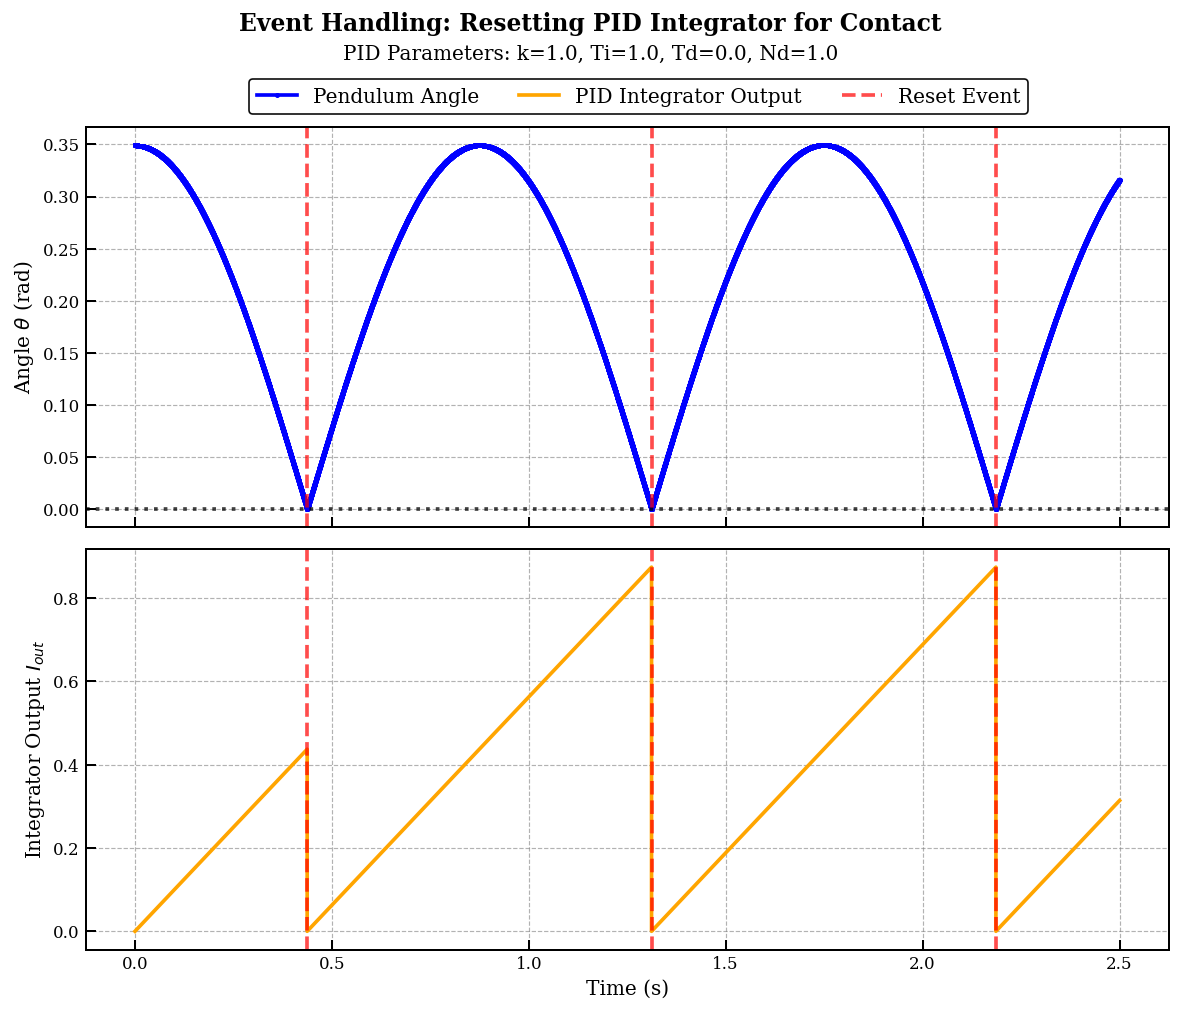

In [7]:
# Plotting results: subplot for pendulum and PID integrator
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

fig.suptitle('Event Handling: Resetting PID Integrator for Contact', fontweight='bold', fontsize=14, y=1.05)

# Add subtitle for PID parameters
fig.text(0.5, 1, f"PID Parameters: k={parameters['k']}, Ti={parameters['Ti']}, Td={parameters['Td']}, Nd={parameters['Nd']}",
         ha='center', fontsize=12)

# Pendulum plot
pendulum_angle_signal = ax1.plot(t_vals, q_vals, label='Pendulum Angle', color='blue', marker='o', markersize=2)
ax1.axhline(y=0, color='black', linestyle=':', alpha=0.75)
event_signals = []
for t_event in event_times:
    event_signal = ax1.axvline(x=t_event, color='red', linestyle='--', alpha=0.7, label='Reset Event' if t_event == event_times[0] else "")
    event_signals.append(event_signal)
ax1.set_ylabel(r'Angle $\theta$ (rad)')
ax1.grid()

# PID Integrator plot
pid_integrator_signal = ax2.plot(t_vals_integrator, I_out_values, label='PID Integrator Output', color='orange')
for t_event in event_times:
    ax2.axvline(x=t_event, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel(r'Integrator Output $I_{out}$')
ax2.grid()

# Legend centred at top
handles = pendulum_angle_signal + pid_integrator_signal + event_signals

labels = [h.get_label() for h in handles[:3]]
fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.54, 0.99))

plt.tight_layout()
plt.savefig('../figures/Hybrid/test_4_event_handling.svg')
plt.show()